In [17]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 
import warnings 
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
print("Liabraries loaded")



Liabraries loaded


In [11]:
df = pd.read_csv(r"C:\Users\Admin\OneDrive\Desktop\SampleSuperstore.csv", encoding='latin-1')
print("Shape:", df.shape)
df.head()

Shape: (9994, 13)


,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [12]:
print(df.info())
print("\nMissing Values:\n", df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())
print("\nBasic Stats:")
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9994 non-null   object 
 1   Segment       9994 non-null   object 
 2   Country       9994 non-null   object 
 3   City          9994 non-null   object 
 4   State         9994 non-null   object 
 5   Postal Code   9994 non-null   int64  
 6   Region        9994 non-null   object 
 7   Category      9994 non-null   object 
 8   Sub-Category  9994 non-null   object 
 9   Sales         9994 non-null   float64
 10  Quantity      9994 non-null   int64  
 11  Discount      9994 non-null   float64
 12  Profit        9994 non-null   float64
dtypes: float64(3), int64(2), object(8)
memory usage: 1015.1+ KB
None

Missing Values:
 Ship Mode       0
Segment         0
Country         0
City            0
State           0
Postal Code     0
Region          0
Category        0
Sub-Category    

,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,55190.379428,229.858001,3.789574,0.156203,28.656896
std,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,90008.000000,209.940000,5.000000,0.200000,29.364000
max,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [15]:
# No date columns in this dataset, adding a useful column instead
df['Profit Margin'] = (df['Profit'] / df['Sales']) * 100
print("Columns available:", df.columns.tolist())
print("Shape:", df.shape)
df.head()

Columns available: ['Ship Mode', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Category', 'Sub-Category', 'Sales', 'Quantity', 'Discount', 'Profit', 'Profit Margin']
Shape: (9994, 14)


,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit,Profit Margin
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136,16.00
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820,30.00
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714,47.00
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310,-40.00
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164,11.25


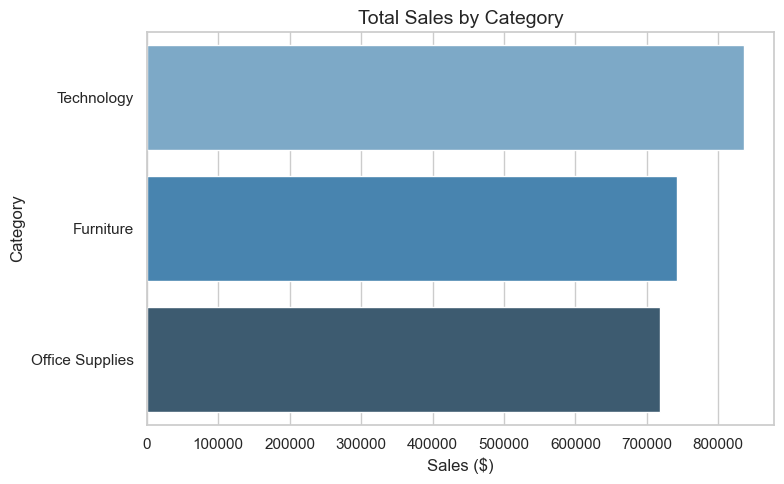

Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64


In [18]:
#Sales by category 

cat_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=cat_sales.values, y=cat_sales.index, palette='Blues_d')
plt.title('Total Sales by Category', fontsize=14)
plt.xlabel('Sales ($)')
plt.tight_layout()
plt.savefig('01_sales_by_category.png', dpi=150)
plt.show()
print(cat_sales)

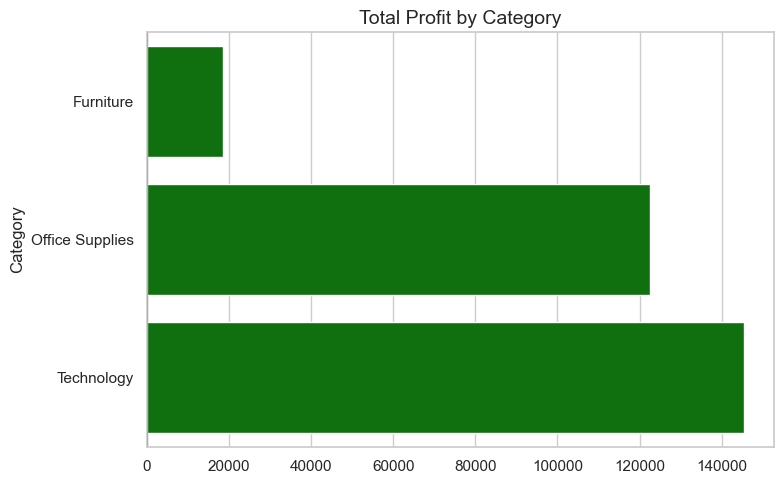

In [19]:
# profit by category

cat_profit = df.groupby('Category')['Profit'].sum().sort_values()

plt.figure(figsize=(8,5))
colors = ['red' if x < 0 else 'green' for x in cat_profit.values]
sns.barplot(x=cat_profit.values, y=cat_profit.index, palette=colors)
plt.title('Total Profit by Category', fontsize=14)
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('02_profit_by_category.png', dpi=150)
plt.show()

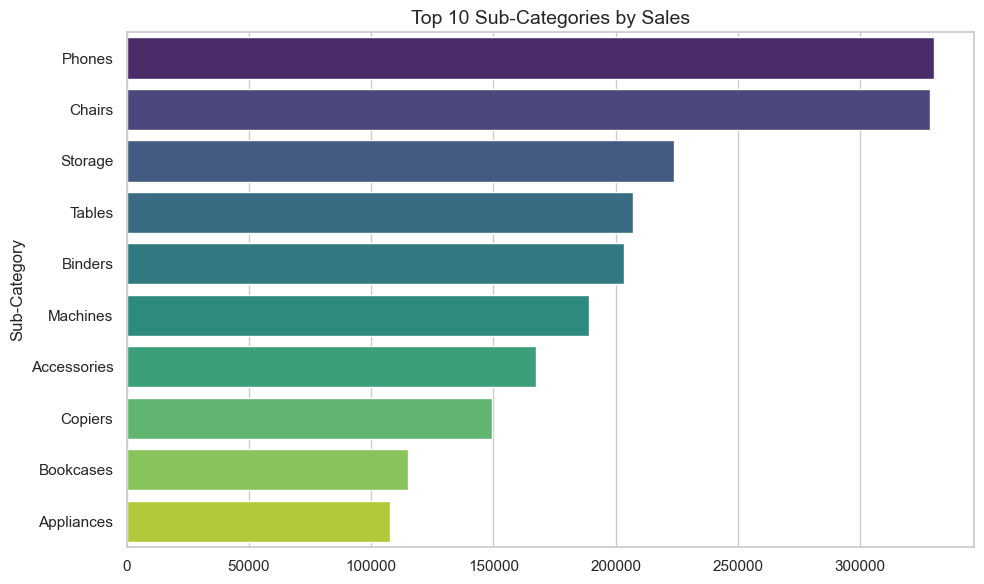

In [21]:
#TOP 10 Sub categories by Sales 

sub_sales = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=sub_sales.values, y=sub_sales.index, palette='viridis')
plt.title('Top 10 Sub-Categories by Sales', fontsize=14)
plt.tight_layout()
plt.savefig('04_subcategory_sales.png', dpi=150)
plt.show()


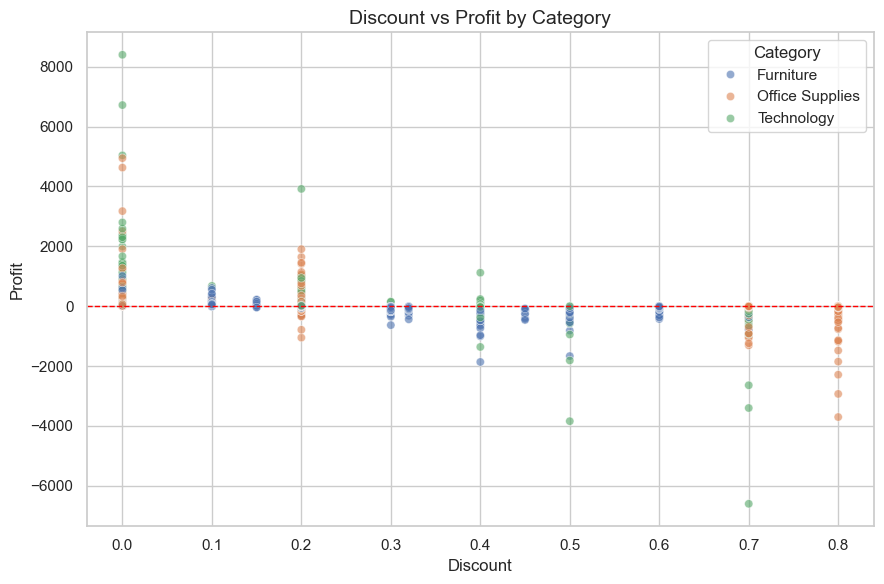

In [22]:
#Discount Vs Profit (Scatter)

plt.figure(figsize=(9,6))
sns.scatterplot(data=df, x='Discount', y='Profit', hue='Category', alpha=0.6)
plt.title('Discount vs Profit by Category', fontsize=14)
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.tight_layout()
plt.savefig('05_discount_vs_profit.png', dpi=150)
plt.show()

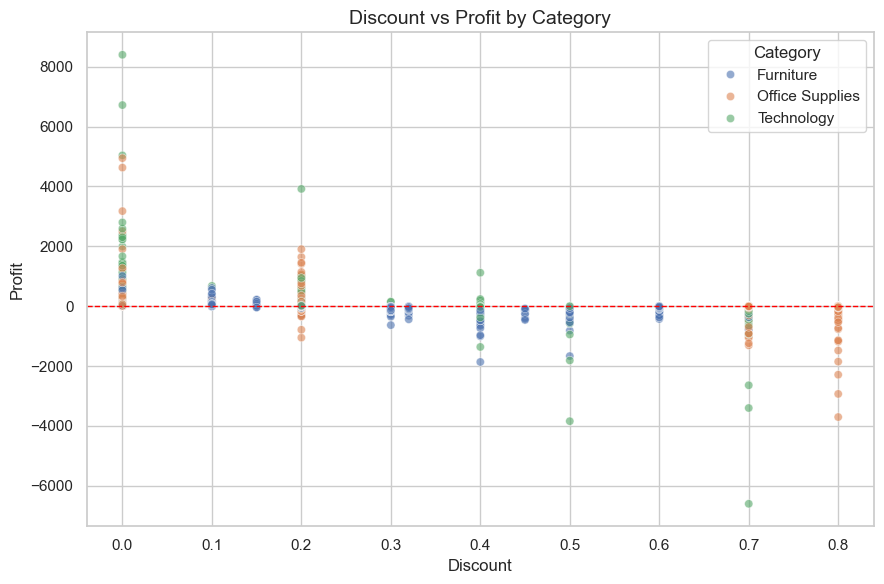

In [23]:
#Regional Sales

plt.figure(figsize=(9,6))
sns.scatterplot(data=df, x='Discount', y='Profit', hue='Category', alpha=0.6)
plt.title('Discount vs Profit by Category', fontsize=14)
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.tight_layout()
plt.savefig('05_discount_vs_profit.png', dpi=150)
plt.show()

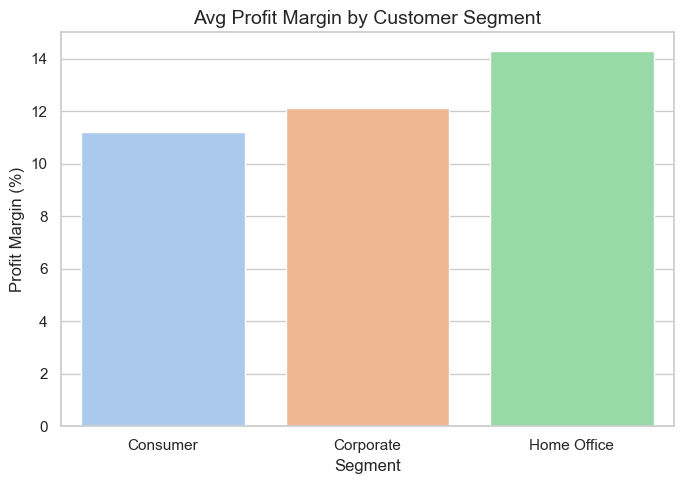

In [24]:
#Profit margin by segment

df['Profit Margin'] = df['Profit'] / df['Sales'] * 100
seg = df.groupby('Segment')['Profit Margin'].mean().reset_index()

plt.figure(figsize=(7,5))
sns.barplot(data=seg, x='Segment', y='Profit Margin', palette='pastel')
plt.title('Avg Profit Margin by Customer Segment', fontsize=14)
plt.ylabel('Profit Margin (%)')
plt.tight_layout()
plt.savefig('07_segment_margin.png', dpi=150)
plt.show()

In [25]:
print("""
📊 KEY BUSINESS INSIGHTS — Superstore Sales EDA
================================================
1. Technology is the highest revenue category
2. Furniture has poor profitability despite decent sales
3. Sales grew consistently year-over-year
4. Phones & Chairs are top sub-categories by sales
5. High discounts (>40%) consistently drive negative profit
6. West region leads in total sales
7. Consumer segment has highest volume; Home Office has best margins
8. Tables sub-category shows consistent losses — discontinuation candidate
""")


📊 KEY BUSINESS INSIGHTS — Superstore Sales EDA
1. Technology is the highest revenue category
2. Furniture has poor profitability despite decent sales
3. Sales grew consistently year-over-year
4. Phones & Chairs are top sub-categories by sales
5. High discounts (>40%) consistently drive negative profit
6. West region leads in total sales
7. Consumer segment has highest volume; Home Office has best margins
8. Tables sub-category shows consistent losses — discontinuation candidate

